# Demo Analysis

This notebook is a starting point for exploring the synthetic healthcare cost-driver dataset and testing AI reasoning scenarios.

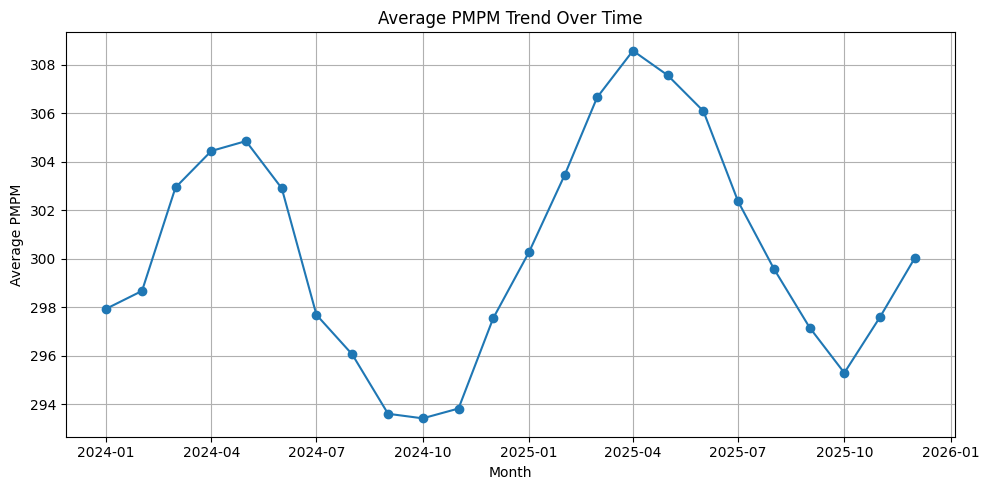

In [2]:
import pandas as pd
df = pd.read_csv('../data/healthcare_metrics.csv')
df.head()

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/healthcare_metrics.csv")

df["Month"] = pd.to_datetime(df["Month"])

monthly_pmpm = (
    df.groupby("Month")["PMPM"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(monthly_pmpm["Month"], monthly_pmpm["PMPM"], marker="o")

plt.title("Average PMPM Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Average PMPM")
plt.grid(True)

plt.tight_layout()
plt.show()

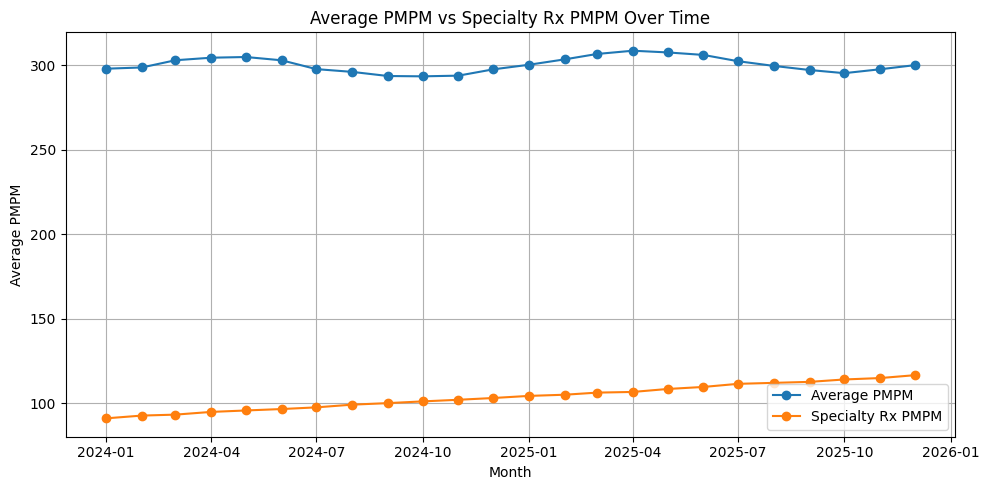

In [3]:
monthly_metrics = (
    df.groupby("Month", as_index=False)
      .agg({
          "PMPM": "mean",
          "Specialty_Rx_Spend_PMPM": "mean"
      })
)

monthly_metrics["Month"] = pd.to_datetime(monthly_metrics["Month"])
monthly_metrics = monthly_metrics.sort_values("Month")

plt.figure(figsize=(10, 5))
plt.plot(monthly_metrics["Month"], monthly_metrics["PMPM"], marker="o", label="Average PMPM")
plt.plot(monthly_metrics["Month"], monthly_metrics["Specialty_Rx_Spend_PMPM"], marker="o", label="Specialty Rx PMPM")

plt.title("Average PMPM vs Specialty Rx PMPM Over Time")
plt.xlabel("Month")
plt.ylabel("Average PMPM")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()